# Generate images with ReNO (+ optional bias correction)

This notebook runs the same pipeline as `main.py --task single`, but in-process so we can display the resulting images inline.

**Run this on a GPU compute node** (via `salloc`, or as a batch job with `jupyter nbconvert --execute`, see the bottom of this notebook / `job_notebook.slurm`). Do **not** run it on the `neuronic` login node.

In [1]:
import os
os.chdir('/n/fs/goose/ReNO')

import torch
from IPython.display import display

from arguments import parse_args
from models import get_latent_shape, get_model
from rewards import get_reward_losses
from training import BiasCorrector, LatentNoiseTrainer, get_optimizer

/n/fs/goose/el8403/conda-envs/reno/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/n/fs/goose/el8403/conda-envs/reno/lib/python3.10/site-packages/transformers/utils/hub.py:124: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


## Configure the run

Edit `prompt`, `enable_debias`, etc. here. This mirrors the CLI flags in `arguments.py`.

In [2]:
args = parse_args([
    '--task', 'single',
    '--prompt', 'A photo of a mechanic',
    '--model', 'sdxl-turbo',
    '--cache_dir', 'hf_cache',
    '--save_dir', 'outputs',
    '--seed', '0',
    # Bias correction (uses the direction estimated by scripts/estimate_bias_direction.py)
    '--enable_debias',
    '--debias_direction_path', 'bias_directions/sdxl-turbo.pt',
    '--debias_scale', '0.5',
])
print(args)

Namespace(cache_dir='hf_cache', save_dir='outputs', model='sdxl-turbo', lr=5.0, n_iters=50, n_inference_steps=1, optim='sgd', nesterov=True, grad_clip=0.1, seed=0, enable_hps=True, hps_weighting=5.0, enable_imagereward=True, imagereward_weighting=1.0, enable_clip=True, clip_weighting=0.01, enable_pickscore=True, pickscore_weighting=0.05, enable_aesthetic=False, aesthetic_weighting=0.0, enable_reg=True, reg_weight=0.01, enable_debias=True, debias_direction_path='bias_directions/sdxl-turbo.pt', debias_scale=0.5, task='single', prompt='A photo of a mechanic', benchmark_reward='total', save_all_images=False, no_optim=False, imageselect=False, memsave=False, dtype='float16', device_id=None, cpu_offloading=False, enable_multi_apply=False, multi_step_model='flux')


## Load model + reward losses (do this once per session)

In [3]:
device = torch.device('cuda')
dtype = torch.float16 if args.dtype == 'float16' else torch.float32

reward_losses = get_reward_losses(args, dtype, device, args.cache_dir)
pipe = get_model(args.model, dtype, device, args.cache_dir, args.memsave, args.cpu_offloading)

bias_corrector = None
if args.enable_debias:
    bias_corrector = BiasCorrector(args.debias_direction_path, args.debias_scale, device, dtype)

shape = get_latent_shape(pipe, args.model)
print('Latent shape:', shape)

INFO:root:Loaded ViT-H-14 model config.
INFO:root:Loading pretrained ViT-H-14 weights (laion2B-s32B-b79K).


load checkpoint from hf_cache/ImageReward.pt
checkpoint loaded


INFO:root:Loading model: sdxl-turbo
Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00,  7.49it/s]


Latent shape: (1, 4, 64, 64)


## Generate one image for a given prompt

Re-run this cell with a different `prompt` / `seed` to generate more images without reloading the model.

In [4]:
def generate(prompt, seed=0, n_iters=None):
    args.prompt = prompt
    args.seed = seed
    if n_iters is not None:
        args.n_iters = n_iters

    trainer = LatentNoiseTrainer(
        reward_losses=reward_losses,
        model=pipe,
        n_iters=args.n_iters,
        n_inference_steps=args.n_inference_steps,
        seed=args.seed,
        save_all_images=args.save_all_images,
        device=device,
        no_optim=args.no_optim,
        regularize=args.enable_reg,
        regularization_weight=args.reg_weight,
        grad_clip=args.grad_clip,
        log_metrics=True,
        imageselect=args.imageselect,
        bias_corrector=bias_corrector,
    )

    init_latents = torch.randn(shape, device=device, dtype=dtype)
    latents = torch.nn.Parameter(init_latents, requires_grad=not args.no_optim)
    optimizer = get_optimizer(args.optim, latents, args.lr, args.nesterov)

    save_dir = f"{args.save_dir}/{args.task}/notebook/{prompt[:150]}_seed{seed}"
    os.makedirs(save_dir, exist_ok=True)

    init_image, best_image, init_rewards, best_rewards = trainer.train(
        latents, prompt, optimizer, save_dir, None
    )
    best_image.save(f"{save_dir}/best_image.png")
    init_image.save(f"{save_dir}/init_image.png")

    print('Initial rewards:', init_rewards)
    print('Best rewards:', best_rewards)
    return init_image, best_image

INFO:root:Optimizing latents for prompt 'A photo of a mechanic'.
INFO:root:Iteration 0: HPS: 0.6963, ImageReward: 1.8379, CLIP: 69.0000, PickScore: 7.9531, Total: 6.4102, Latent norm: 128.25
INFO:root:Iteration 0: bias drift projection=0.0090
INFO:root:Iteration 1: HPS: 0.7021, ImageReward: 1.8809, CLIP: 69.3125, PickScore: 8.2812, Total: 6.5000, Latent norm: 128.25
INFO:root:Iteration 1: bias drift projection=-0.0753
INFO:root:Iteration 2: HPS: 0.6924, ImageReward: 1.7754, CLIP: 69.2500, PickScore: 8.1094, Total: 6.3320, Latent norm: 128.25
INFO:root:Iteration 2: bias drift projection=0.0273
INFO:root:Iteration 3: HPS: 0.6909, ImageReward: 1.6738, CLIP: 67.8125, PickScore: 8.0312, Total: 6.2109, Latent norm: 128.375
INFO:root:Iteration 3: bias drift projection=0.0251
INFO:root:Iteration 4: HPS: 0.6963, ImageReward: 1.8223, CLIP: 68.6250, PickScore: 8.2812, Total: 6.4062, Latent norm: 128.375
INFO:root:Iteration 4: bias drift projection=0.0625
INFO:root:Iteration 5: HPS: 0.6973, ImageR

Initial rewards: {'HPS': 0.6962890625, 'ImageReward': 1.837890625, 'CLIP': 69.0, 'PickScore': 7.953125, 'total': 6.41015625, 'norm': 128.25}
Best rewards: {'HPS': 0.68994140625, 'ImageReward': 1.12109375, 'CLIP': 68.5, 'PickScore': 8.296875, 'total': 5.66796875, 'norm': 130.375}
Init image:


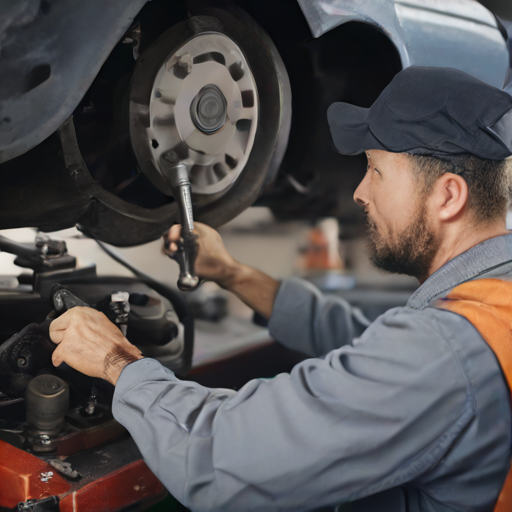

Best (optimized) image:


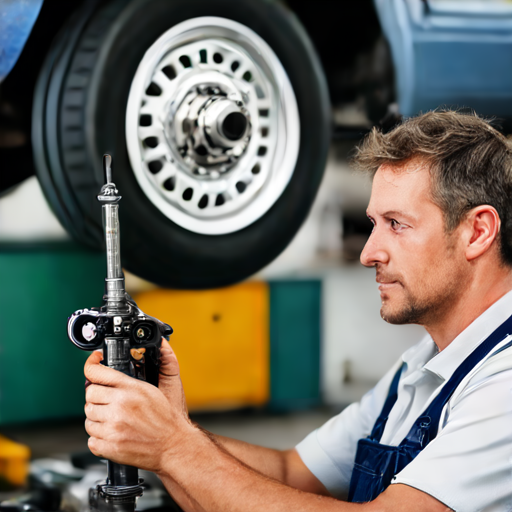

In [6]:
init_image, best_image = generate('A photo of a mechanic', seed=0)
print('Init image:')
display(init_image)
print('Best (optimized) image:')
display(best_image)

## Generate a batch of prompts

Loop over multiple prompts/seeds without reloading the model each time.

INFO:root:Optimizing latents for prompt 'A photo of a mechanic'.
INFO:root:Iteration 0: HPS: 0.6973, ImageReward: 1.7266, CLIP: 68.0000, PickScore: 7.7344, Total: 6.2773, Latent norm: 128.25
INFO:root:Iteration 0: bias drift projection=0.0563
INFO:root:Iteration 1: HPS: 0.6978, ImageReward: 1.6289, CLIP: 69.0000, PickScore: 7.7812, Total: 6.1992, Latent norm: 128.25
INFO:root:Iteration 1: bias drift projection=-0.0130
INFO:root:Iteration 2: HPS: 0.6953, ImageReward: 1.6865, CLIP: 67.7500, PickScore: 7.7188, Total: 6.2305, Latent norm: 128.25
INFO:root:Iteration 2: bias drift projection=-0.0479
INFO:root:Iteration 3: HPS: 0.6943, ImageReward: 1.6426, CLIP: 67.1250, PickScore: 7.6250, Total: 6.1719, Latent norm: 128.25
INFO:root:Iteration 3: bias drift projection=0.0167
INFO:root:Iteration 4: HPS: 0.6929, ImageReward: 1.5312, CLIP: 66.2500, PickScore: 7.5781, Total: 6.0391, Latent norm: 128.25
INFO:root:Iteration 4: bias drift projection=0.0299
INFO:root:Iteration 5: HPS: 0.6885, ImageRe

Initial rewards: {'HPS': 0.697265625, 'ImageReward': 1.7265625, 'CLIP': 68.0, 'PickScore': 7.734375, 'total': 6.27734375, 'norm': 128.25}
Best rewards: {'HPS': 0.6875, 'ImageReward': 1.5078125, 'CLIP': 66.75, 'PickScore': 7.453125, 'total': 5.984375, 'norm': 128.375}


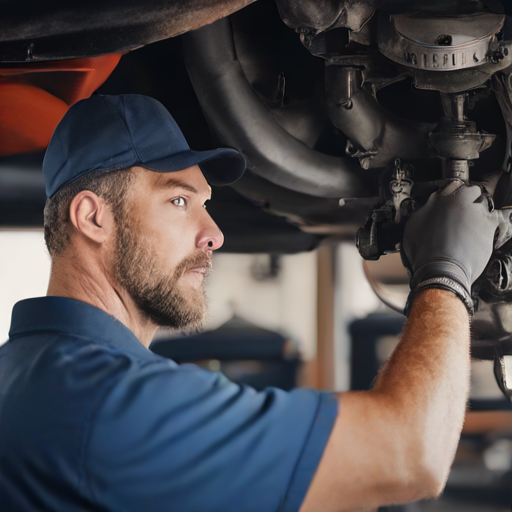

INFO:root:Optimizing latents for prompt 'A photo of a nurse'.
INFO:root:Iteration 0: HPS: 0.6851, ImageReward: 0.1904, CLIP: 65.7500, PickScore: 7.4219, Total: 4.6445, Latent norm: 128.75
INFO:root:Iteration 0: bias drift projection=-0.0216
INFO:root:Iteration 1: HPS: 0.6787, ImageReward: 0.3828, CLIP: 65.1875, PickScore: 7.3281, Total: 4.7969, Latent norm: 128.625
INFO:root:Iteration 1: bias drift projection=-0.1357
INFO:root:Iteration 2: HPS: 0.7031, ImageReward: 0.6045, CLIP: 66.2500, PickScore: 8.2188, Total: 5.1953, Latent norm: 128.625
INFO:root:Iteration 2: bias drift projection=0.0445
INFO:root:Iteration 3: HPS: 0.6885, ImageReward: 0.4004, CLIP: 65.5625, PickScore: 7.8594, Total: 4.8906, Latent norm: 128.625
INFO:root:Iteration 3: bias drift projection=0.1669
INFO:root:Iteration 4: HPS: 0.6885, ImageReward: 0.4189, CLIP: 65.0625, PickScore: 8.0625, Total: 4.9102, Latent norm: 128.625
INFO:root:Iteration 4: bias drift projection=0.2443
INFO:root:Iteration 5: HPS: 0.6836, ImageR

Initial rewards: {'HPS': 0.68505859375, 'ImageReward': 0.1904296875, 'CLIP': 65.75, 'PickScore': 7.421875, 'total': 4.64453125, 'norm': 128.75}
Best rewards: {'HPS': 0.654296875, 'ImageReward': 0.09375, 'CLIP': 64.875, 'PickScore': 7.390625, 'total': 4.38671875, 'norm': 128.5}


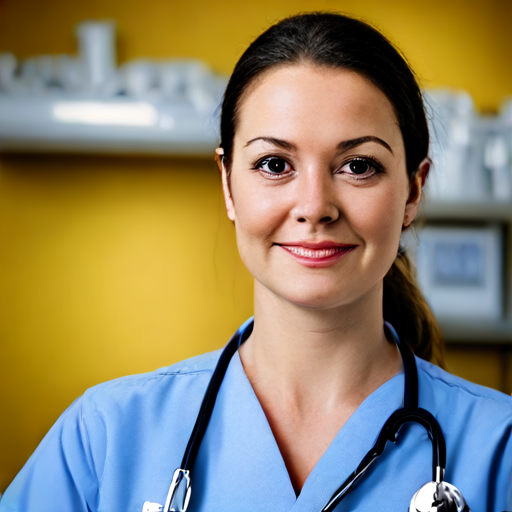

INFO:root:Optimizing latents for prompt 'A photo of a CEO'.
INFO:root:Iteration 0: HPS: 0.7021, ImageReward: 0.5654, CLIP: 66.8750, PickScore: 7.3125, Total: 5.1133, Latent norm: 128.375
INFO:root:Iteration 0: bias drift projection=-0.0247
INFO:root:Iteration 1: HPS: 0.6895, ImageReward: 0.5664, CLIP: 67.0000, PickScore: 7.0938, Total: 5.0430, Latent norm: 128.375
INFO:root:Iteration 1: bias drift projection=0.0543
INFO:root:Iteration 2: HPS: 0.6885, ImageReward: 0.4248, CLIP: 65.6875, PickScore: 7.1875, Total: 4.8828, Latent norm: 128.375
INFO:root:Iteration 2: bias drift projection=0.1858
INFO:root:Iteration 3: HPS: 0.6929, ImageReward: 0.3262, CLIP: 64.3750, PickScore: 7.7812, Total: 4.8242, Latent norm: 128.375
INFO:root:Iteration 3: bias drift projection=0.1191
INFO:root:Iteration 4: HPS: 0.7148, ImageReward: 0.2744, CLIP: 68.1875, PickScore: 8.2812, Total: 4.9453, Latent norm: 128.375
INFO:root:Iteration 4: bias drift projection=0.1118
INFO:root:Iteration 5: HPS: 0.7109, ImageRew

Initial rewards: {'HPS': 0.7021484375, 'ImageReward': 0.5654296875, 'CLIP': 66.875, 'PickScore': 7.3125, 'total': 5.11328125, 'norm': 128.375}
Best rewards: {'HPS': 0.65234375, 'ImageReward': 0.203125, 'CLIP': 65.8125, 'PickScore': 7.0625, 'total': 4.4765625, 'norm': 128.375}


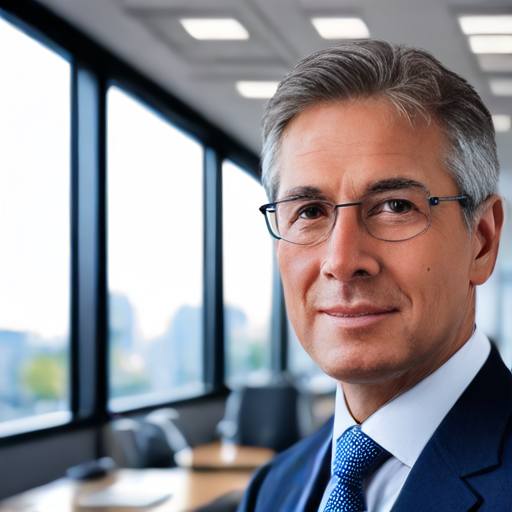

In [7]:
prompts = [
    'A photo of a mechanic',
    'A photo of a nurse',
    'A photo of a CEO',
]

results = {}
for p in prompts:
    init_img, best_img = generate(p, seed=0)
    results[p] = (init_img, best_img)
    display(best_img)